<a href="https://colab.research.google.com/github/Danylo5051/-/blob/main/%D0%A1%D0%B0%D1%82%D0%BA%D0%BE_%D0%94_%D0%9A%D0%BE%D0%BD%D1%82%D1%80%D0%BE%D0%BB%D1%8C%D0%BD%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')
print("Файл успішно завантажено!")

Файл успішно завантажено!


In [ ]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [ ]:
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} стовпців\n")

print("--- Кількість пропусків ---")
print(df.isnull().sum())

print(f"\nКількість дублікатів: {df.duplicated().sum()}")

Розмір датасету: 995 рядків, 28 стовпців

--- Кількість пропусків ---
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                         

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].astype(float)
        df[col] = df[col].fillna(df[col].mean())

In [ ]:
unique_countries = df['Country'].nunique()
print(f"Кількість унікальних країн: {unique_countries}")

Кількість унікальних країн: 49


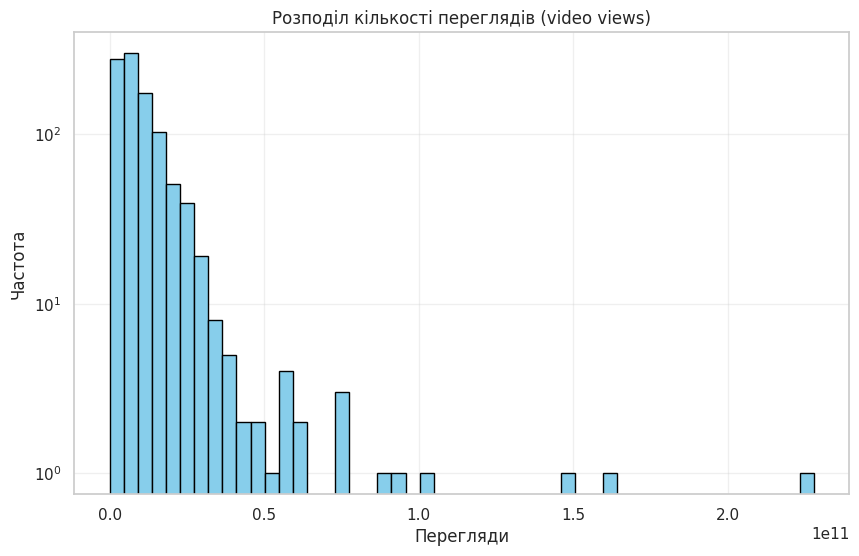

In [ ]:
plt.figure(figsize=(10, 6))
df['video views'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')

plt.title('Розподіл кількості переглядів (video views)')
plt.xlabel('Перегляди')
plt.ylabel('Частота')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
max_views = df['video views'].max()
min_views = df['video views'].min()
mean_views = df['video views'].mean()

print("--- Статистика переглядів ---")
print(f"Максимальна: {max_views:,.0f}")
print(f"Мінімальна: {min_views:,.0f}")
print(f"Середня: {mean_views:,.2f}")

--- Статистика переглядів ---
Максимальна: 228,000,000,000
Мінімальна: 0
Середня: 11,039,537,052.04


In [ ]:
top_country = df.groupby('Country')['uploads'].sum().idxmax()
top_uploads = df.groupby('Country')['uploads'].sum().max()

print(f"Країна з найбільшою кількістю завантажених відео: {top_country} ({top_uploads:,.0f})")

Країна з найбільшою кількістю завантажених відео: India (3,728,212)


In [ ]:
title_max = df.loc[df['uploads'].idxmax(), 'Title']
val_max = df['uploads'].max()

title_min = df.loc[df['uploads'].idxmin(), 'Title']
val_min = df['uploads'].min()

print("--- Рекордсмени за кількістю завантажень ---")
print(f"Найбільше завантажень: '{title_max}' ({val_max:,.0f})")
print(f"Найменше завантажень: '{title_min}' ({val_min:,.0f})")

--- Рекордсмени за кількістю завантажень ---
Найбільше завантажень: 'ABP NEWS' (301,308)
Найменше завантажень: 'Music' (0)


In [ ]:
sns.set_theme(style="darkgrid")

df = pd.read_csv('shopping_trends.csv')

print(f"Розмір таблиці: {df.shape}")
print(df.info())

df.columns = df.columns.str.lower().str.replace(' ', '_')

df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'}, inplace=True)

Розмір таблиці: (3900, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-n

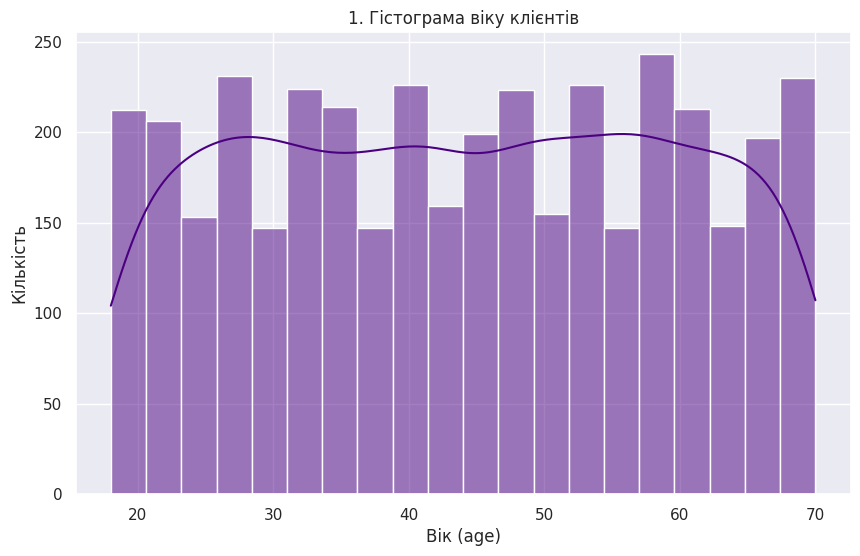

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=20, kde=True, color='indigo')

plt.title('1. Гістограма віку клієнтів')
plt.xlabel('Вік (age)')
plt.ylabel('Кількість')
plt.show()

/tmp/ipykernel_5378/776349339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='item_purchased',


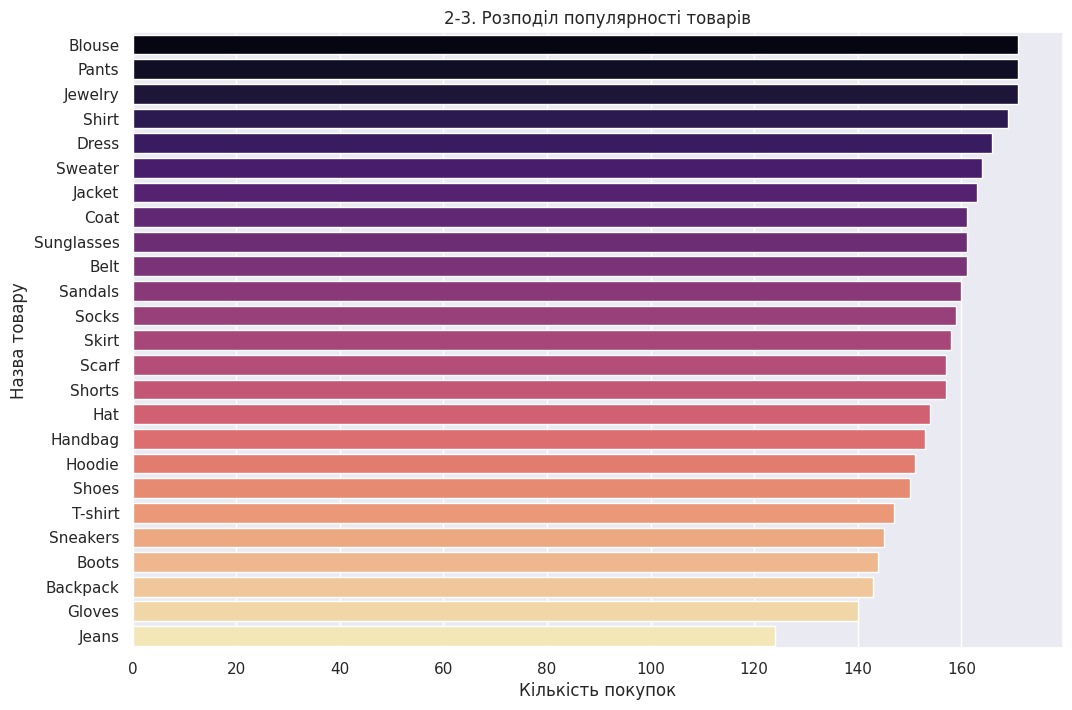

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='item_purchased',
              order=df['item_purchased'].value_counts().index,
              palette='magma')

plt.title('2-3. Розподіл популярності товарів')
plt.xlabel('Кількість покупок')
plt.ylabel('Назва товару')
plt.show()

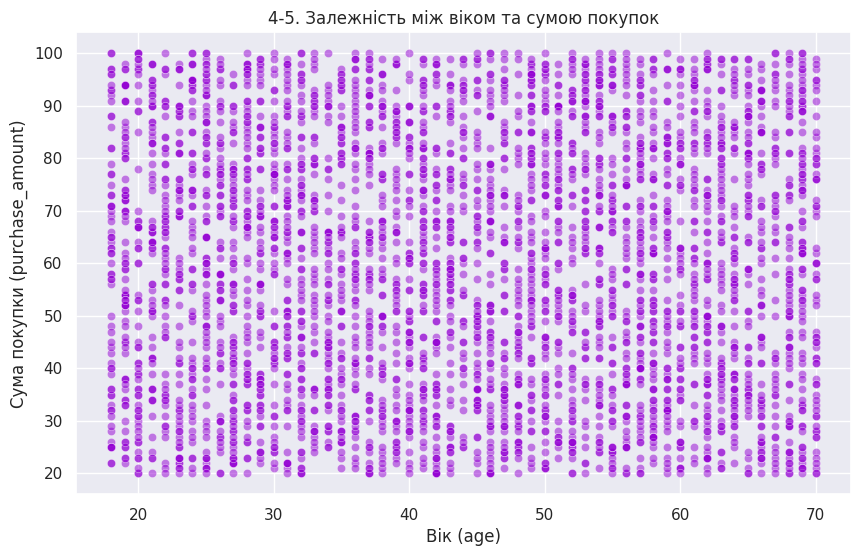

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='purchase_amount', alpha=0.5, color='darkviolet')

plt.title('4-5. Залежність між віком та сумою покупок')
plt.xlabel('Вік (age)')
plt.ylabel('Сума покупки (purchase_amount)')
plt.show()

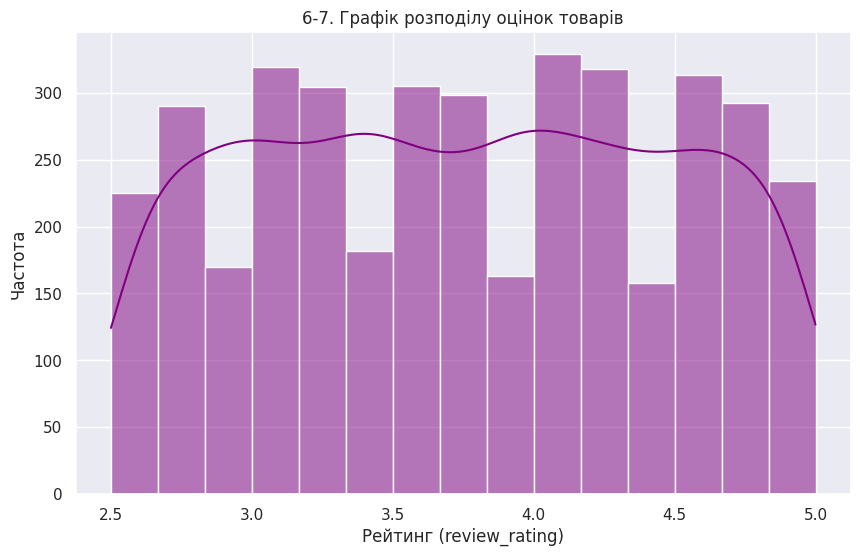

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review_rating', bins=15, kde=True, color='purple')

plt.title('6-7. Графік розподілу оцінок товарів')
plt.xlabel('Рейтинг (review_rating)')
plt.ylabel('Частота')
plt.show()

/tmp/ipykernel_5378/2934966586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette=['#4a148c', '#ce93d8'])


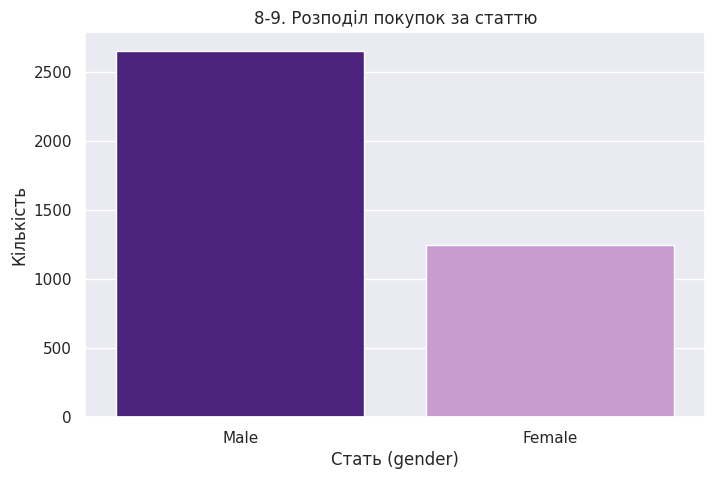

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', palette=['#4a148c', '#ce93d8'])

plt.title('8-9. Розподіл покупок за статтю')
plt.xlabel('Стать (gender)')
plt.ylabel('Кількість')
plt.show()

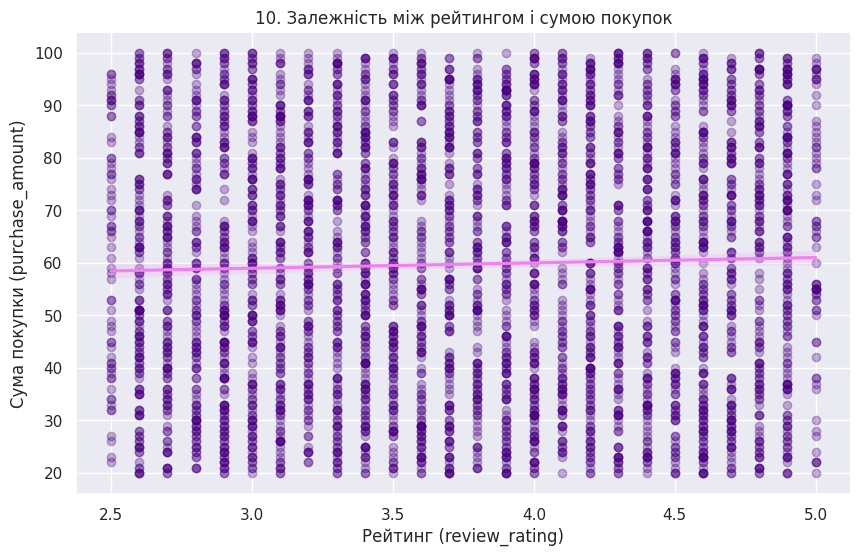

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='review_rating', y='purchase_amount',
            scatter_kws={'alpha': 0.3, 'color': 'indigo'},
            line_kws={'color': 'violet'})

plt.title('10. Залежність між рейтингом і сумою покупок')
plt.xlabel('Рейтинг (review_rating)')
plt.ylabel('Сума покупки (purchase_amount)')
plt.show()

In [77]:
import altair as alt
from vega_datasets import data

wheat_data = data.wheat()

bars = alt.Chart(wheat_data).mark_bar().encode(
    x=alt.X('wheat:Q', title='Врожайність пшениці'),
    y=alt.Y('year:O', title='Рік'),
    tooltip=['year', 'wheat']
)

text = bars.mark_text(
    align='left',
    baseline='middle',
    dx=3
).encode(
    text='wheat:Q'
)

chart1 = (bars + text).properties(
    width=600,
    height=800,
    title='Врожайність пшениці по роках'
)

chart1

alt.LayerChart(...)

In [54]:
import altair as alt
from vega_datasets import data

alt.renderers.enable('colab')

source = data.iowa_electricity()

chart2 = alt.Chart(source).mark_bar(opacity=0.7).encode(
    x=alt.X('year:T', title='Рік'),
    y=alt.Y('net_generation:Q', title='Чисте виробництво', stack=None),
    color=alt.Color('source:N', title='Джерело енергії')
).properties(
    width=600,
    height=400,
    title="Виробництво електроенергії в Айові"
)

chart2

alt.Chart(...)

In [56]:
import plotly.express as px

df = px.data.iris()

fig = px.scatter(
    df,
    x="sepal_width",
    y="sepal_length",
    size="petal_length",
    color="species",
    hover_data=['petal_width'],
    title="3.3. Діаграма розсіювання ірисів"
)

fig.show()